# K-Nearest Neighbors (KNN)

## 1. Descripción

K-Nearest Neighbors (KNN) es un algoritmo que clasifica una nueva observación en función de las observaciones más parecidas que ya conoce dentro del conjunto de entrenamiento. Cuando llega un dato nuevo, el algoritmo calcula la distancia entre ese dato y todos los puntos del conjunto de entrenamiento, identifica cuales son los K puntos más cercanos y le asigna la clase que más se repite entre esos K vecinos.

Con respecto al entrenamiento, que no se realiza en una fase separada, consiste en almacenar todos los datos de entrada y calcular las distancias en el momento en que se le pide predecir una nueva instancia.

### 1.1. Tipos de Entrada

Los tipos de datos que recibe deben ser variables numéricas continuas, ya que el algoritmo depende directamente de calcular distancias entre los puntos. Adicionalmente, el algoritmo necesita que las variables se encuentren en la misma escala, por lo cual se deben aplicar técnicas de normalización o estandarización cuando sea necesario.

### 1.2. Casos de Uso

El algoritmo KNN es adecuado cuando se tiene un conjunto de datos con variables numéricas que pueden normalizarse o estandarizarse, la relación entre las clases no puede modelarse con una función lineal y el volumen de datos no es tan grande como para que el cálculo de distancias en tiempo de predicción sea costoso.

Siguiendo estas condiciones, sus aplicaciones más comunes incluyen los sistemas de recomendación que sugieren productos según usuarios con preferencias similares, el diagnóstico médico al clasificar pacientes según casos previos con diagnósticos confirmados, el reconocimiento de patrones e imágenes al comparar una imagen nueva con imágenes ya etiquetadas y la detección de fraude al marcar como sospechosa una transacción que difiere significativamente de los patrones habituales de sus vecinos más cercanos.


## 2. BibTeX y Referencias

@article{fix1951discriminatory,

  title={Discriminatory Analysis-Nonparametric Discrimination: Consistency Properties},

  author={Fix, Evelyn and Hodges Jr, JL},

  year={1951}

}

@article{cover1967nearest,

  title={Nearest neighbor pattern
  classification},

  author={Cover, T and Hart, P},

  journal={IEEE Transactions on Information Theory},

  volume={13},

  number={1},

  pages={21--27},

  year={1967},

  publisher={IEEE}

}

@article{peterson2009k,

  title={K-nearest neighbor},

  author={Peterson, Leif E},

  journal={Scholarpedia},

  volume={4},

  number={2},

  pages={1883},

  year={2009}
  
}

## 3. Tipo de Modelo



* Método de Aprendizaje: aprendizaje supervisado
* Por Parámetros: no paramétrico
* Datos de Aprendizaje: aprendizaje Offline
* Resultado del Entrenamiento: basado en instancias





## 4. Algoritmo de Entrenamiento

Búsqueda del vecino más cercano (nearest neighbor) basada en el cálculo de distancias utilizando fuerza bruta.

## 5. Supuestos y Restricciones

* No paramétrico: no asume una distribución específica de los datos.
* No requiere linealidad: no asume una relación lineal entre las variables, por lo cual puede modelar relaciones no lineales entre ellas.
* Homogeneidad local: asume que instancias cercanas en el espacio de variables pertenecen a la misma clase o tienen valores similares.
* Escala de las variables: requiere que las variables estén en la misma escala, ya que el cálculo se basa en distancias.
* Sensibilidad a variables irrelevantes: es sensible a variables irrelevantes o ruidosas, ya que todas las variables participan en el cálculo de la distancia.
* Sensibilidad al desbalance de clases: puede sesgar la predicción hacia la clase mayoritaria cuando las clases no están balanceadas.
* Costo computacional: El costo en tiempo de predicción crece con el tamaño del conjunto de entrenamiento, ya que se calculan distancias contra todos los puntos almacenados.

## 6. Source Code de K-Nearest Neighbors (KNN)





### Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

np.random.seed(42)

### Datos

In [ ]:
# Dataset Wine: 178 muestras, 13 variables químicas, 3 clases de vino
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df["clase"] = pd.Categorical.from_codes(y, class_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


### División de los Datos

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 142 muestras | Prueba: 36 muestras


### Estandarización de Variables

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Entrenamiento del Modelo

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Precisión (K=5): {acc:.3f}")

Precisión (K=5): 0.972


### Matriz de Confusión

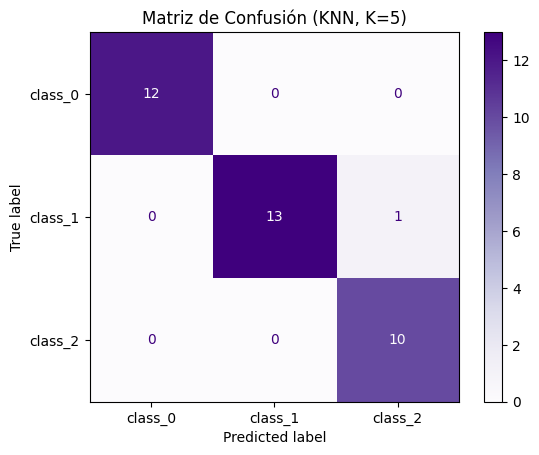

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión (KNN, K=5)")
plt.show()

### Reporte de Clasificación

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



### Selección del Mejor Valor K

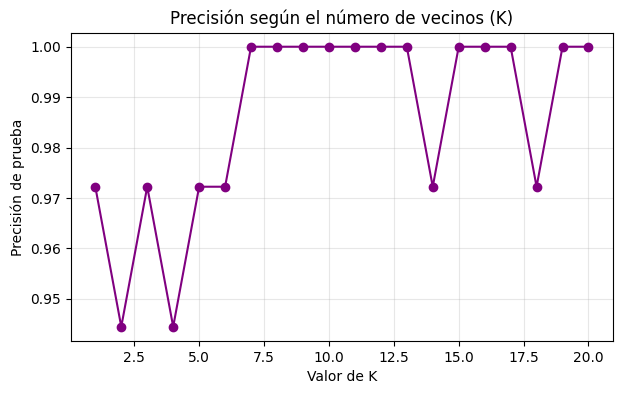

Mejor valor de K: 7 (precisión: 1.000)


In [ ]:
# Se prueban diferentes valores de K para encontrar la mejor precisión sobre los datos de prueba
k_values = range(1, 21)
accuracies = []

for k in k_values:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracies, marker="o", color="purple")
plt.xlabel("Valor de K")
plt.ylabel("Precisión de prueba")
plt.title("Precisión según el número de vecinos (K)")
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Mejor valor de K: {best_k} (precisión: {max(accuracies):.3f})")

### Entrenar los datos con el Mejor valor K

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

y_pred_best = best_knn.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Precisión con K={best_k}: {acc_best:.3f}")

Precisión con K=7: 1.000


### Predicción sobre Nuevos Datos

In [ ]:
# Se seleccionan 3 vinos reales de los datos de prueba que el modelo no utilizó durante el entrenamiento
sample_positions = [0, 1, 2]

for pos in sample_positions:
    real = class_names[y_test[pos]]
    predicho = class_names[best_knn.predict(X_test_scaled[pos].reshape(1, -1))[0]]
    print(f"Real: {real:10s} | Predicho: {predicho:10s}")

Real: class_0    | Predicho: class_0   
Real: class_2    | Predicho: class_2   
Real: class_0    | Predicho: class_0   


### Importancia de Variables (Permutation Importance)

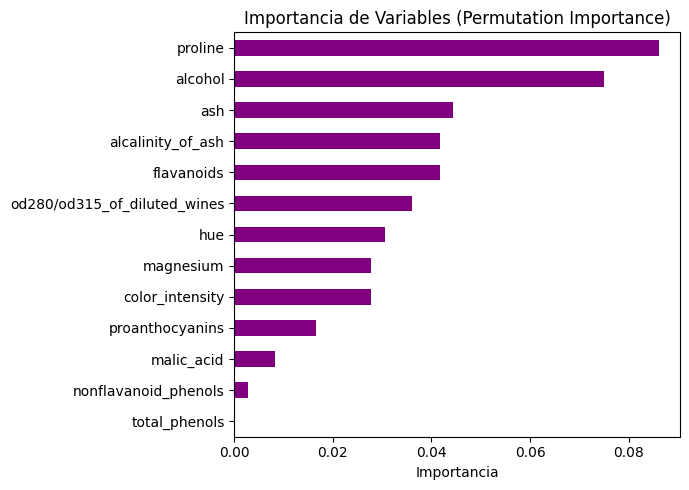

In [ ]:
# KNN no tiene un atributo nativo de importancia de variables, ya que no genera un modelo explícito, por lo que se usa permutation importance
from sklearn.inspection import permutation_importance

result = permutation_importance(best_knn, X_test_scaled, y_test, n_repeats=10, random_state=42)
importances = pd.Series(result.importances_mean, index=feature_names).sort_values()

plt.figure(figsize=(7, 5))
importances.plot(kind="barh", color="purple")
plt.xlabel("Importancia")
plt.title("Importancia de Variables (Permutation Importance)")
plt.tight_layout()
plt.show()

### Visualización de las Fronteras de Decisión (2 Variables)

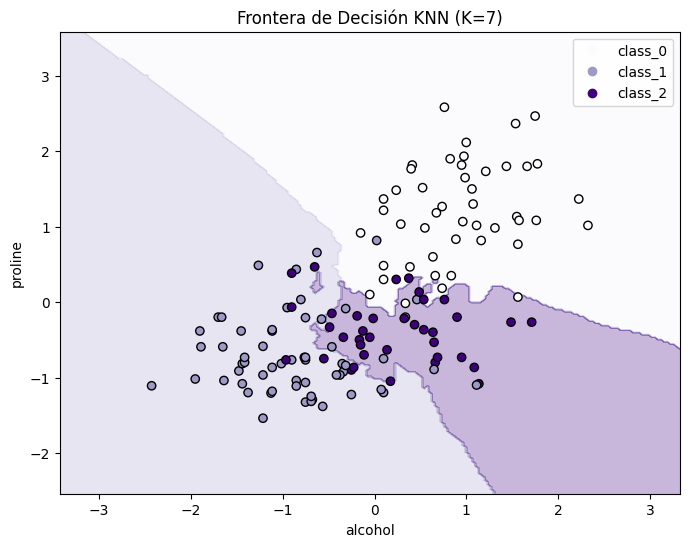

In [ ]:
# Para visualizar las fronteras de decisión se utilizaron solo dos variables, las que resultaron más importantes según el paso anterior
top_2_features = importances.index[-2:].tolist()
idx = [feature_names.index(f) for f in top_2_features]

X_2d = X_train_scaled[:, idx]
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_2d, y_train)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="Purples")
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap="Purples", edgecolor="k")
plt.xlabel(top_2_features[0])
plt.ylabel(top_2_features[1])
plt.title(f"Frontera de Decisión KNN (K={best_k})")
plt.legend(handles=scatter.legend_elements()[0], labels=list(class_names))
plt.show()

### Resultados

Utilizando el dataset Wine el modelo KNN entrenado con K=5 obtuvo una precisión (accuracy) del 97% sobre el conjunto de prueba. El reporte de clasificación mostró que la clase 0 se clasificó perfectamente, mientras que el único error observado fue una instancia de la clase 1 clasificada como clase 2, lo cual refleja que estas dos clases comparten valores químicos más parecidos entre sí que la clase 0.

La búsqueda del mejor valor de K mostró que la precisión varía según el número de vecinos considerados, encontrando que K=7 ofrece el mejor resultado, alcanzando una precisión perfecta de 100% sobre el conjunto de prueba. El análisis de importancia de variables mostró que no todas las variables químicas contribuyen de la misma forma a la clasificación, lo cual se refleja en la visualización de la frontera de decisión, construida únicamente con las dos variables más relevantes, donde se observan regiones diferenciadas para cada clase de vino.